# Chapter 05 Cross Validation: rendered figures

Executed preview for browsing on GitHub (static image output, since GitHub's notebook viewer cannot run the interactive JS the live book uses). The source of truth for regenerating the book's figures is `chapter-05-cross-validation-plots.py`. Run that script directly, not this notebook, to update `_generated/`.

In [1]:
"""
Interactive figures for "Cross-Validation and Model Selection".

Every function builds one self-contained, standalone Plotly HTML page and writes it
to ../_generated/. The matching chapter-cv-cross-validation.md file embeds each page
in an <iframe>, so the chapter never depends on a live Python kernel to render.

Run directly to regenerate every figure:
    python chapter-cv-cross-validation-plots.py
"""

import os

import numpy as np
import plotly.graph_objects as go
from scipy import stats

RNG = np.random.default_rng(42)
OUT_DIR = os.path.join(os.path.dirname(os.path.abspath(__file__)), "..", "_generated")
os.makedirs(OUT_DIR, exist_ok=True)


def save(fig: go.Figure, name: str) -> str:
    path = os.path.join(OUT_DIR, f"{name}.html")
    fig.write_html(path, include_plotlyjs="cdn", full_html=True)
    return path


def true_function(x):
    return 40 + 0.9 * x + 0.004 * x**2


def make_dataset(n=60, noise=25, seed=0):
    rng = np.random.default_rng(seed)
    x = rng.uniform(0, 100, n)
    y = true_function(x) + rng.normal(0, noise, n)
    return x, y


def fit_poly_train_test_error(x_train, y_train, x_test, y_test, degree):
    coeffs = np.polyfit(x_train, y_train, degree)
    pred_train = np.polyval(coeffs, x_train)
    pred_test = np.polyval(coeffs, x_test)
    train_mse = np.mean((pred_train - y_train) ** 2)
    test_mse = np.mean((pred_test - y_test) ** 2)
    return train_mse, test_mse


# ---------------------------------------------------------------------------
# Figure 1: training error keeps falling, test error is U-shaped
# ---------------------------------------------------------------------------
def fig_train_vs_test_error() -> go.Figure:
    x_train, y_train = make_dataset(n=40, seed=1)
    x_test, y_test = make_dataset(n=200, seed=99)
    degrees = list(range(1, 13))
    train_errs, test_errs = [], []
    for d in degrees:
        tr, te = fit_poly_train_test_error(x_train, y_train, x_test, y_test, d)
        train_errs.append(tr)
        test_errs.append(te)

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=degrees, y=train_errs, mode="lines+markers",
                              name="Training error", line=dict(color="#4C78A8")))
    fig.add_trace(go.Scatter(x=degrees, y=test_errs, mode="lines+markers",
                              name="Test error (held-out data)", line=dict(color="#E45756")))
    best_d = degrees[int(np.argmin(test_errs))]
    fig.add_vline(x=best_d, line=dict(color="#54A24B", dash="dot"),
                  annotation_text=f"lowest test error: degree {best_d}")
    fig.update_layout(
        title="Training error keeps falling; test error is U-shaped",
        xaxis_title="Model flexibility (polynomial degree)",
        yaxis_title="Mean squared error",
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


# ---------------------------------------------------------------------------
# Figure 2: variance of the test-error estimate across validation strategies
# ---------------------------------------------------------------------------
def fig_validation_strategy_variance() -> go.Figure:
    strategies = ["Single 50/50\nvalidation split", "5-fold CV", "10-fold CV", "Leave-one-out CV"]
    n_repeats = 60
    n = 40
    degree = 3
    results = {s: [] for s in strategies}

    for rep in range(n_repeats):
        x, y = make_dataset(n=n, seed=1000 + rep)

        # single validation split (a fresh random split each repeat)
        idx = RNG.permutation(n)
        half = n // 2
        tr_idx, va_idx = idx[:half], idx[half:]
        _, mse = fit_poly_train_test_error(x[tr_idx], y[tr_idx], x[va_idx], y[va_idx], degree)
        results["Single 50/50\nvalidation split"].append(mse)

        for k, label in [(5, "5-fold CV"), (10, "10-fold CV"), (n, "Leave-one-out CV")]:
            folds = np.array_split(RNG.permutation(n), k)
            fold_mses = []
            for fold in folds:
                mask = np.ones(n, dtype=bool)
                mask[fold] = False
                if mask.sum() < degree + 2 or len(fold) == 0:
                    continue
                _, mse = fit_poly_train_test_error(x[mask], y[mask], x[fold], y[fold], degree)
                fold_mses.append(mse)
            results[label].append(np.mean(fold_mses))

    fig = go.Figure()
    colors = ["#F58518", "#4C78A8", "#54A24B", "#B279A2"]
    for strat, color in zip(strategies, colors):
        fig.add_trace(go.Box(y=results[strat], name=strat, marker_color=color, boxmean=True))
    fig.update_layout(
        title="Estimated test error across 60 repeats, by validation strategy",
        yaxis_title="Estimated mean squared error",
        margin=dict(t=60, l=60, r=30, b=80),
    )
    return fig


# ---------------------------------------------------------------------------
# Figure 3: choosing regularization strength (lambda) by k-fold CV
# ---------------------------------------------------------------------------
def ridge_fit_predict(x_train, y_train, x_test, lam, degree=3):
    Xtr = np.vander(x_train / 50.0, degree + 1, increasing=True)
    Xte = np.vander(x_test / 50.0, degree + 1, increasing=True)
    p = Xtr.shape[1]
    penalty = lam * np.eye(p)
    penalty[0, 0] = 0.0
    beta = np.linalg.solve(Xtr.T @ Xtr + penalty, Xtr.T @ y_train)
    return Xte @ beta


def fig_lambda_selection() -> go.Figure:
    x, y = make_dataset(n=50, noise=30, seed=7)
    lambdas = np.logspace(-2, 3, 40)
    k_values = [3, 10]
    frames = []
    for k in k_values:
        folds = np.array_split(RNG.permutation(len(x)), k)
        cv_curve = []
        for lam in lambdas:
            fold_mses = []
            for fold in folds:
                mask = np.ones(len(x), dtype=bool)
                mask[fold] = False
                pred = ridge_fit_predict(x[mask], y[mask], x[fold], lam)
                fold_mses.append(np.mean((pred - y[fold]) ** 2))
            cv_curve.append(np.mean(fold_mses))
        best_lam = lambdas[int(np.argmin(cv_curve))]
        frames.append(
            go.Frame(
                name=f"k={k}",
                data=[go.Scatter(x=lambdas, y=cv_curve, mode="lines+markers",
                                  line=dict(color="#4C78A8"))],
                layout=go.Layout(
                    shapes=[dict(type="line", x0=best_lam, x1=best_lam, y0=0, y1=1,
                                 yref="paper", line=dict(color="#E45756", dash="dot"))],
                    annotations=[dict(x=np.log10(best_lam), y=1.05, yref="paper",
                                       xref="x", showarrow=False,
                                       text=f"CV-selected lambda = {best_lam:.2f}",
                                       font=dict(color="#E45756"))],
                ),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="k-fold CV error as regularization strength (lambda) changes",
        xaxis_title="lambda",
        xaxis_type="log",
        yaxis_title="Cross-validated mean squared error",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Number of folds: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=90, l=60, r=30, b=50),
    )
    return fig


# ---------------------------------------------------------------------------
# Figure 4: Bayesian analog, expected log predictive density (ELPD) via PSIS-LOO
# ---------------------------------------------------------------------------
def fig_elpd_by_complexity() -> go.Figure:
    x_train, y_train = make_dataset(n=40, seed=1)
    x_test, y_test = make_dataset(n=300, seed=321)
    degrees = list(range(1, 11))
    elpd_approx = []
    for d in degrees:
        coeffs = np.polyfit(x_train, y_train, d)
        resid_train = y_train - np.polyval(coeffs, x_train)
        sigma = np.std(resid_train) + 1e-6
        pred_test = np.polyval(coeffs, x_test)
        # approximate held-out log predictive density under a Gaussian likelihood,
        # standing in for what PSIS-LOO estimates from posterior draws
        log_dens = stats.norm.logpdf(y_test, loc=pred_test, scale=sigma)
        elpd_approx.append(np.sum(log_dens) / len(x_test) * len(x_train))

    best_d = degrees[int(np.argmax(elpd_approx))]
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=degrees, y=elpd_approx, mode="lines+markers",
                              line=dict(color="#72B7B2")))
    fig.add_vline(x=best_d, line=dict(color="#E45756", dash="dot"),
                  annotation_text=f"highest ELPD: degree {best_d}")
    fig.update_layout(
        title="Expected log predictive density (ELPD) by model complexity",
        xaxis_title="Model flexibility (polynomial degree)",
        yaxis_title="Approximate ELPD (higher is better)",
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


FIGURES = {
    "chapter-cv-fig-train-vs-test-error": fig_train_vs_test_error,
    "chapter-cv-fig-validation-strategy-variance": fig_validation_strategy_variance,
    "chapter-cv-fig-lambda-selection": fig_lambda_selection,
    "chapter-cv-fig-elpd-by-complexity": fig_elpd_by_complexity,
}


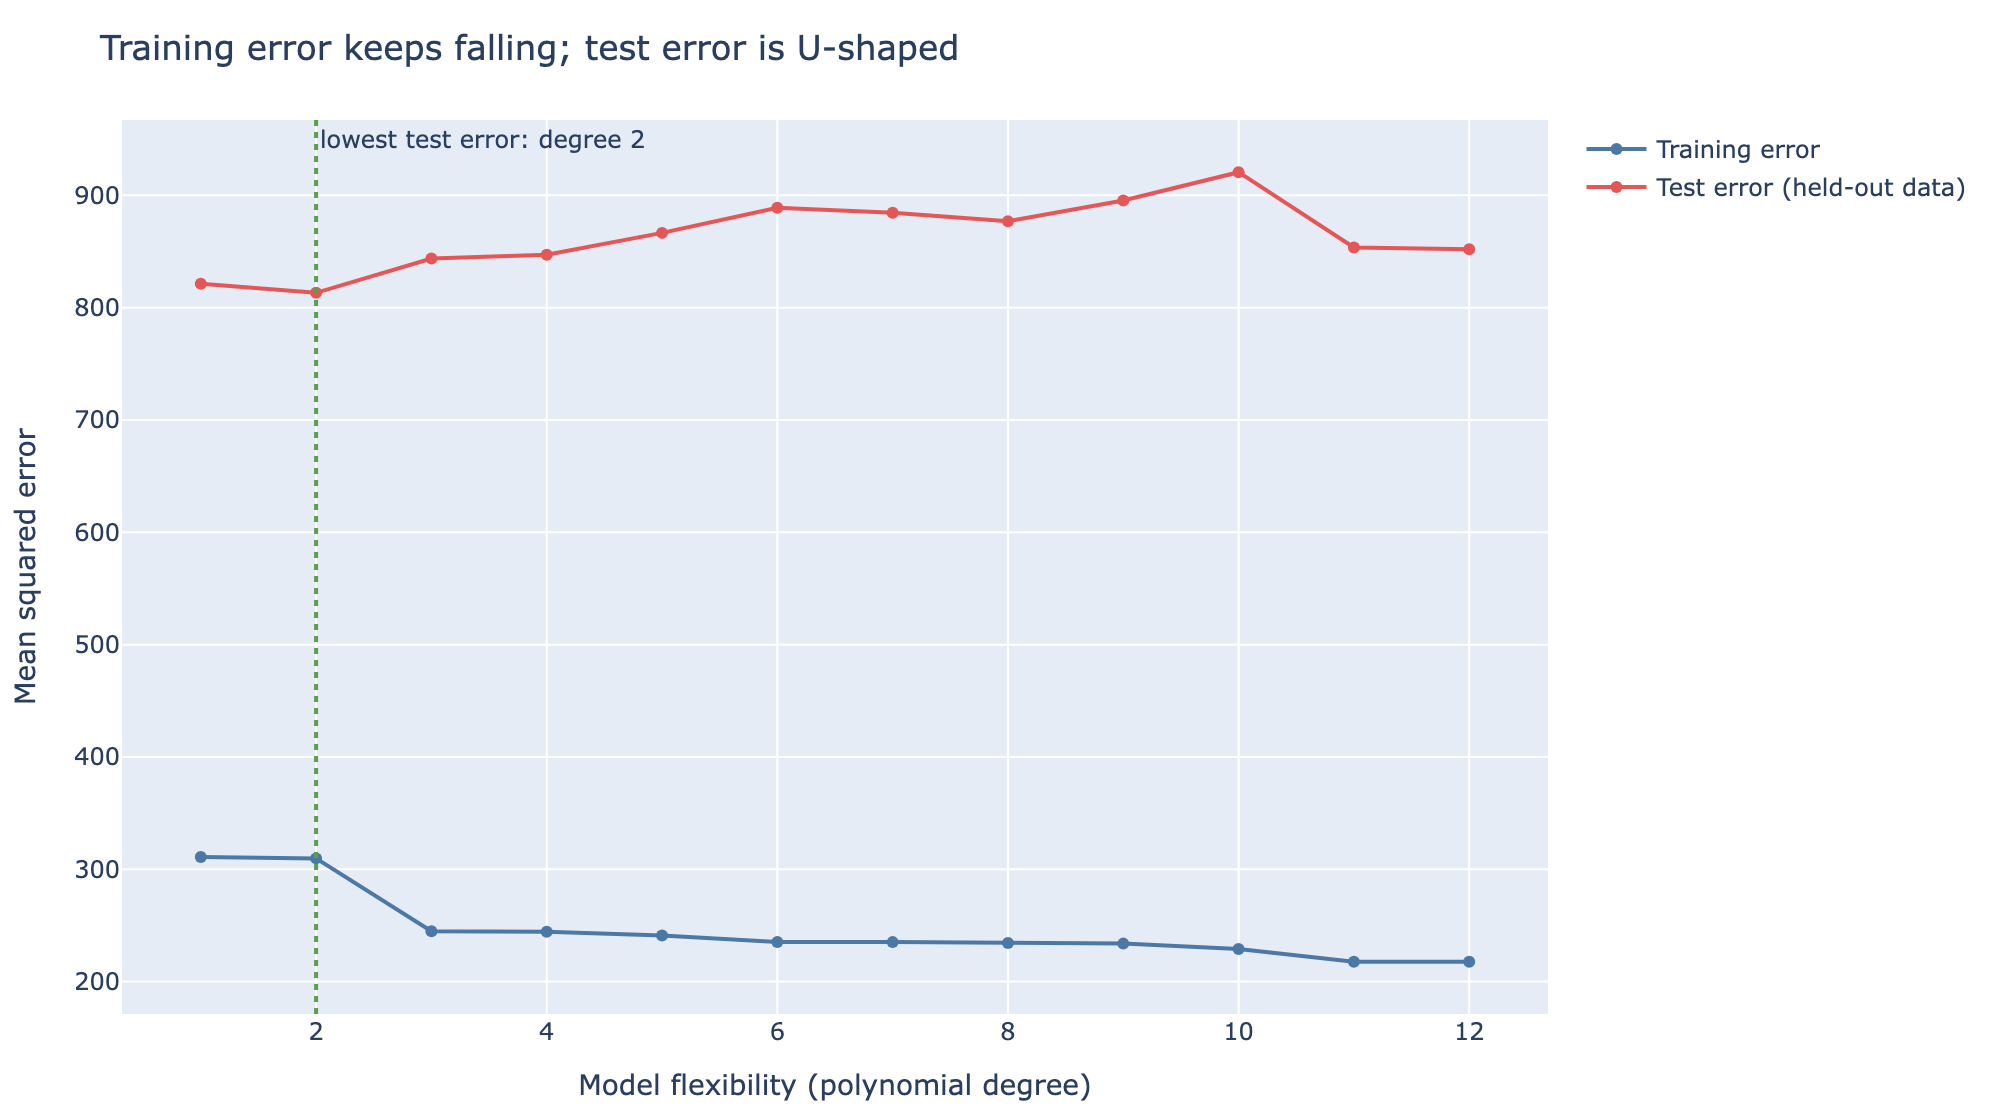

In [2]:
fig = FIGURES["chapter-cv-fig-train-vs-test-error"]()
fig

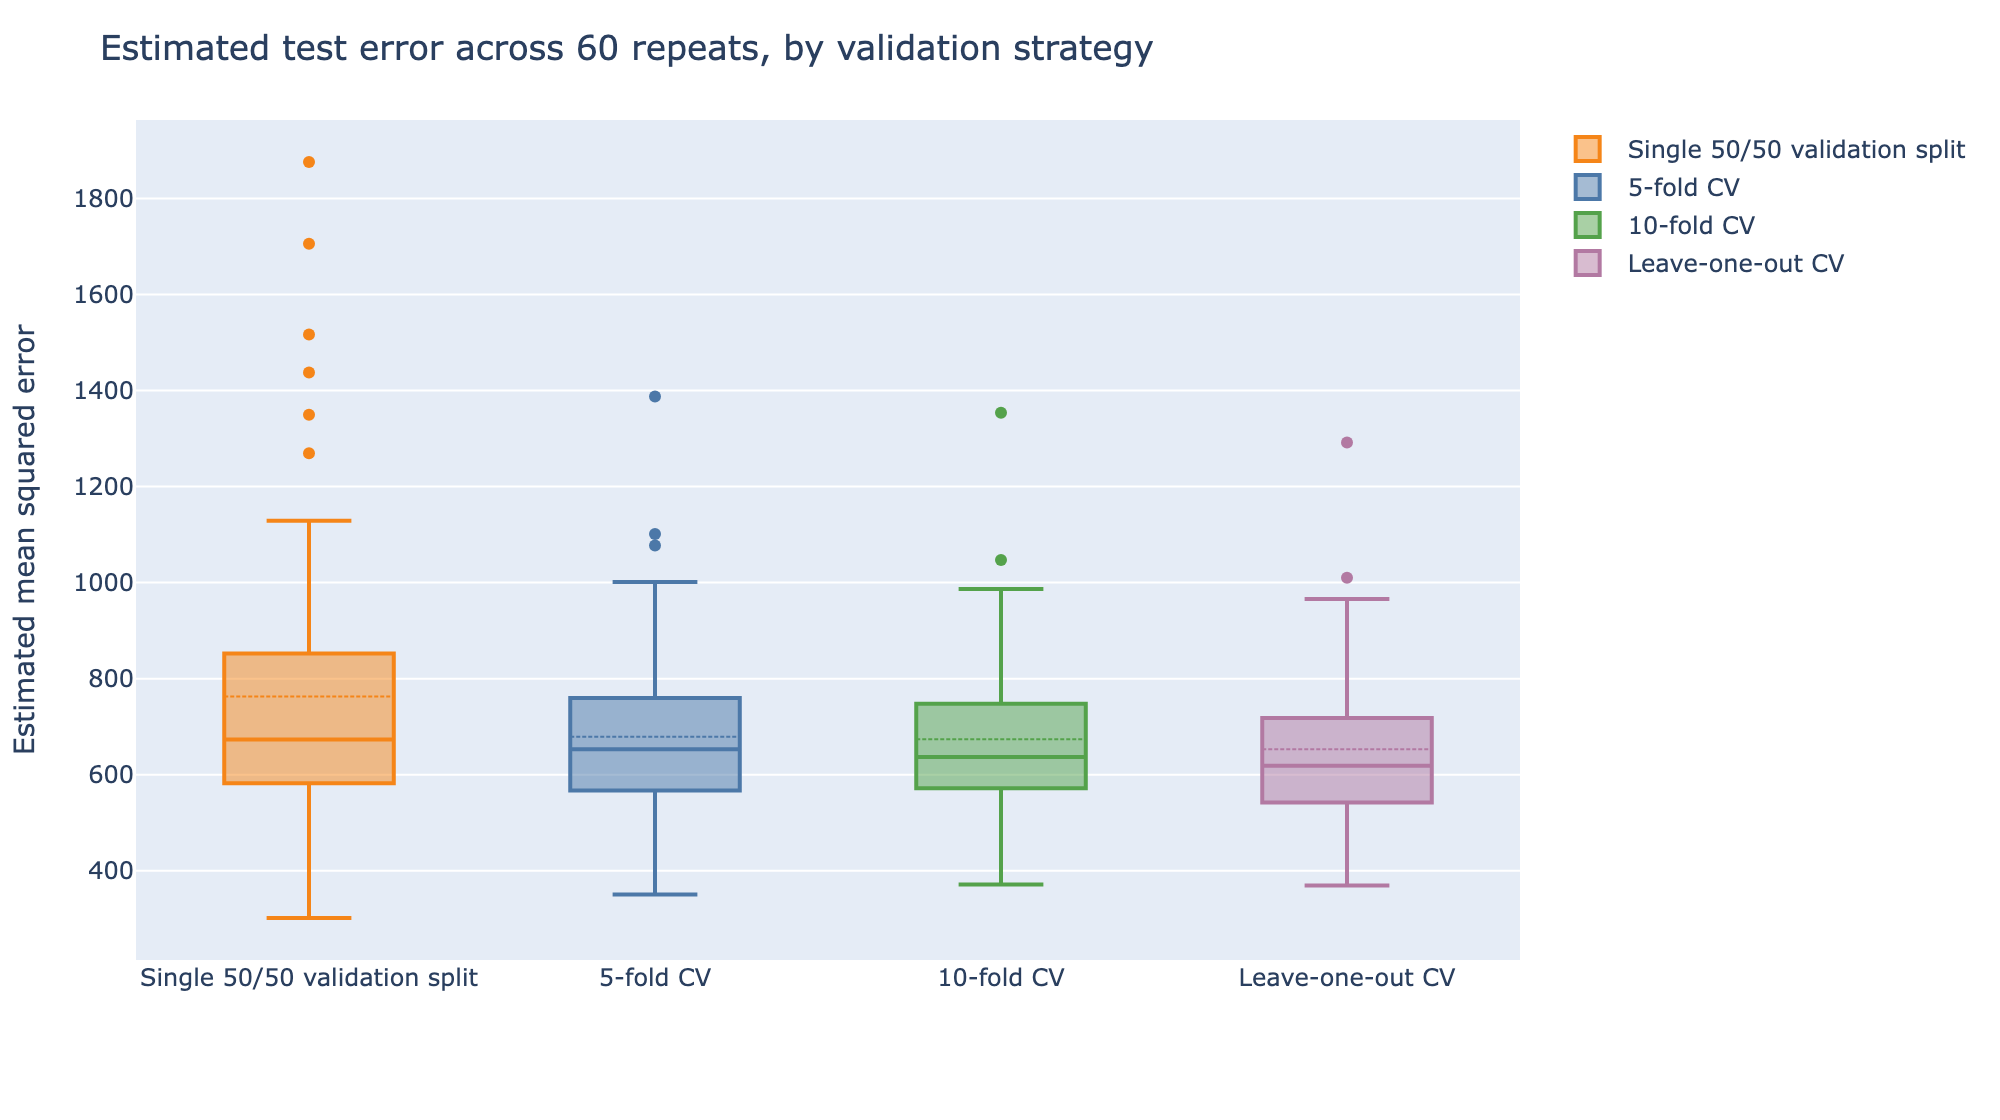

In [3]:
fig = FIGURES["chapter-cv-fig-validation-strategy-variance"]()
fig

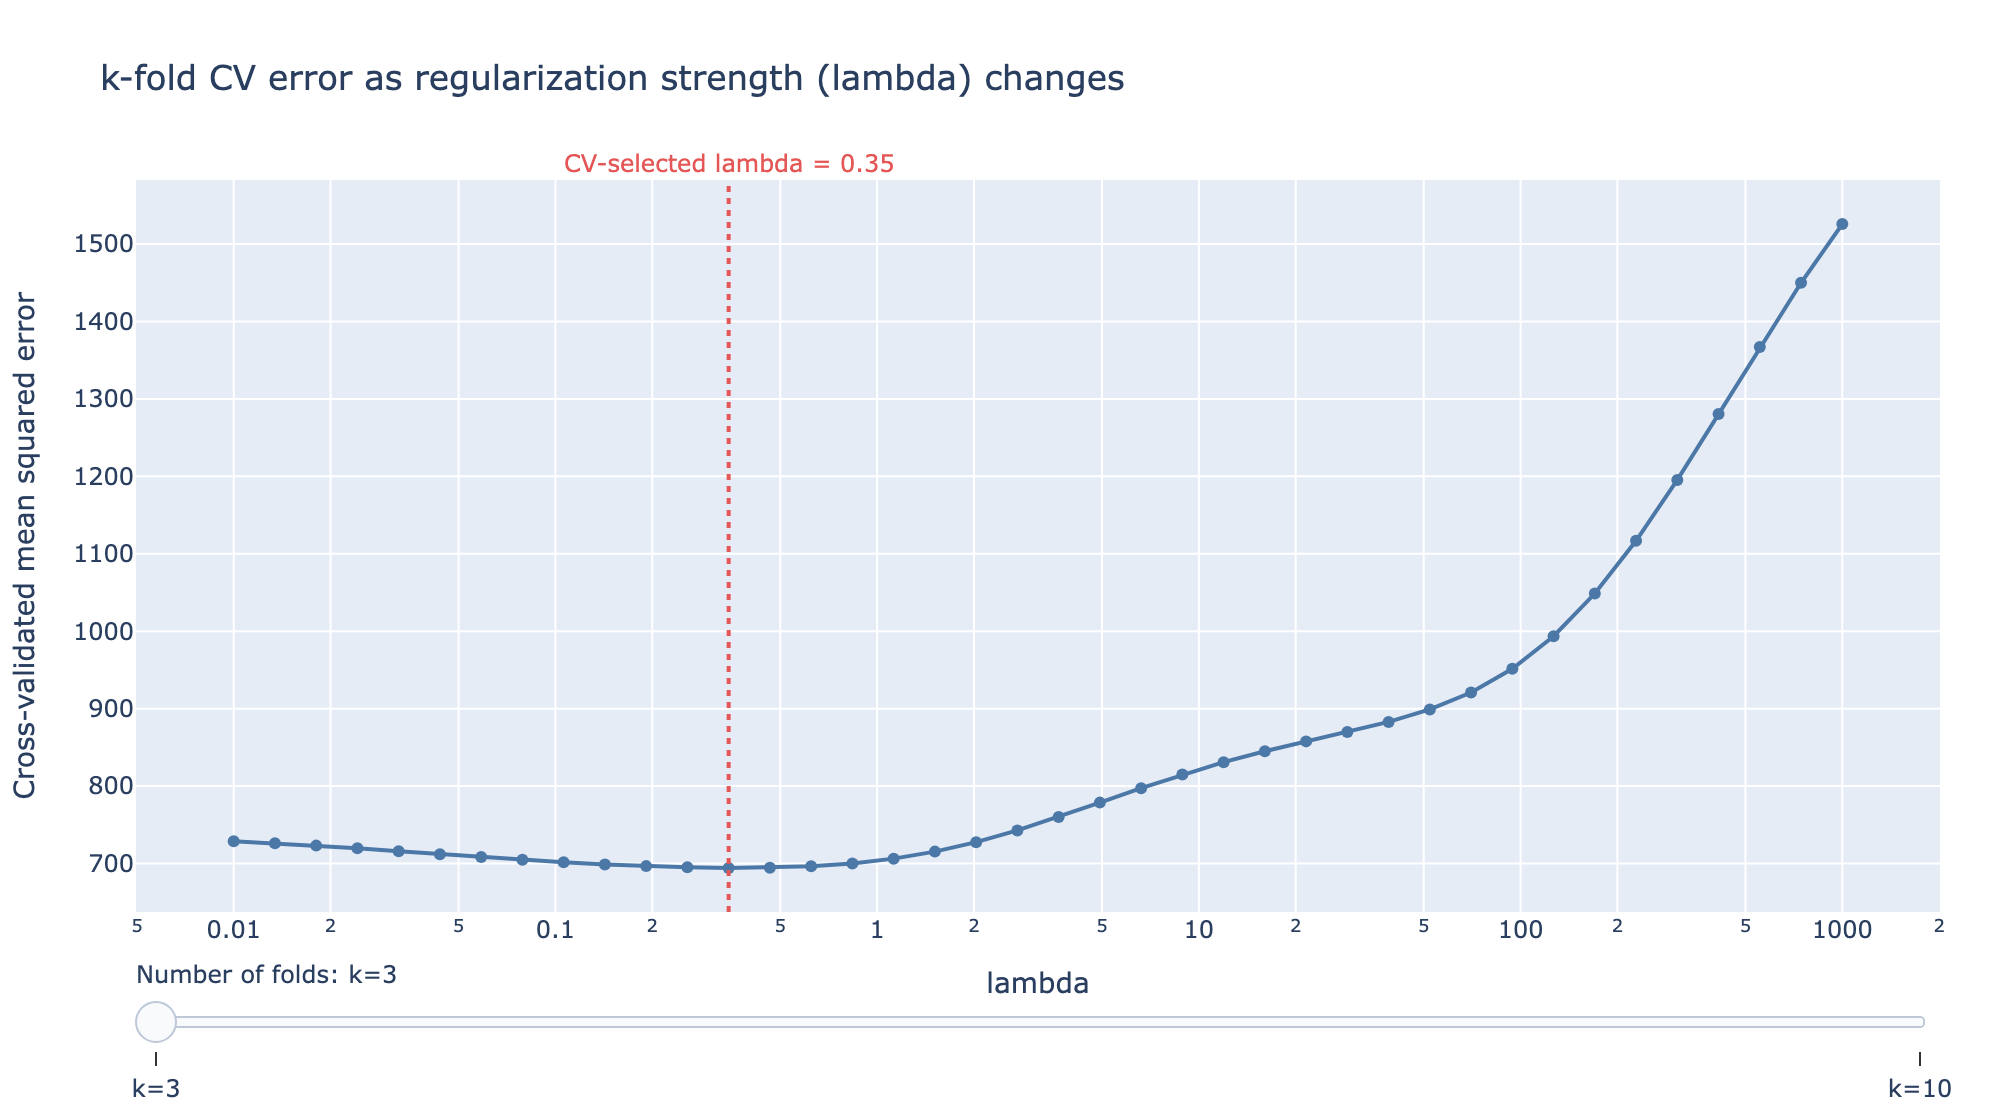

In [4]:
fig = FIGURES["chapter-cv-fig-lambda-selection"]()
fig

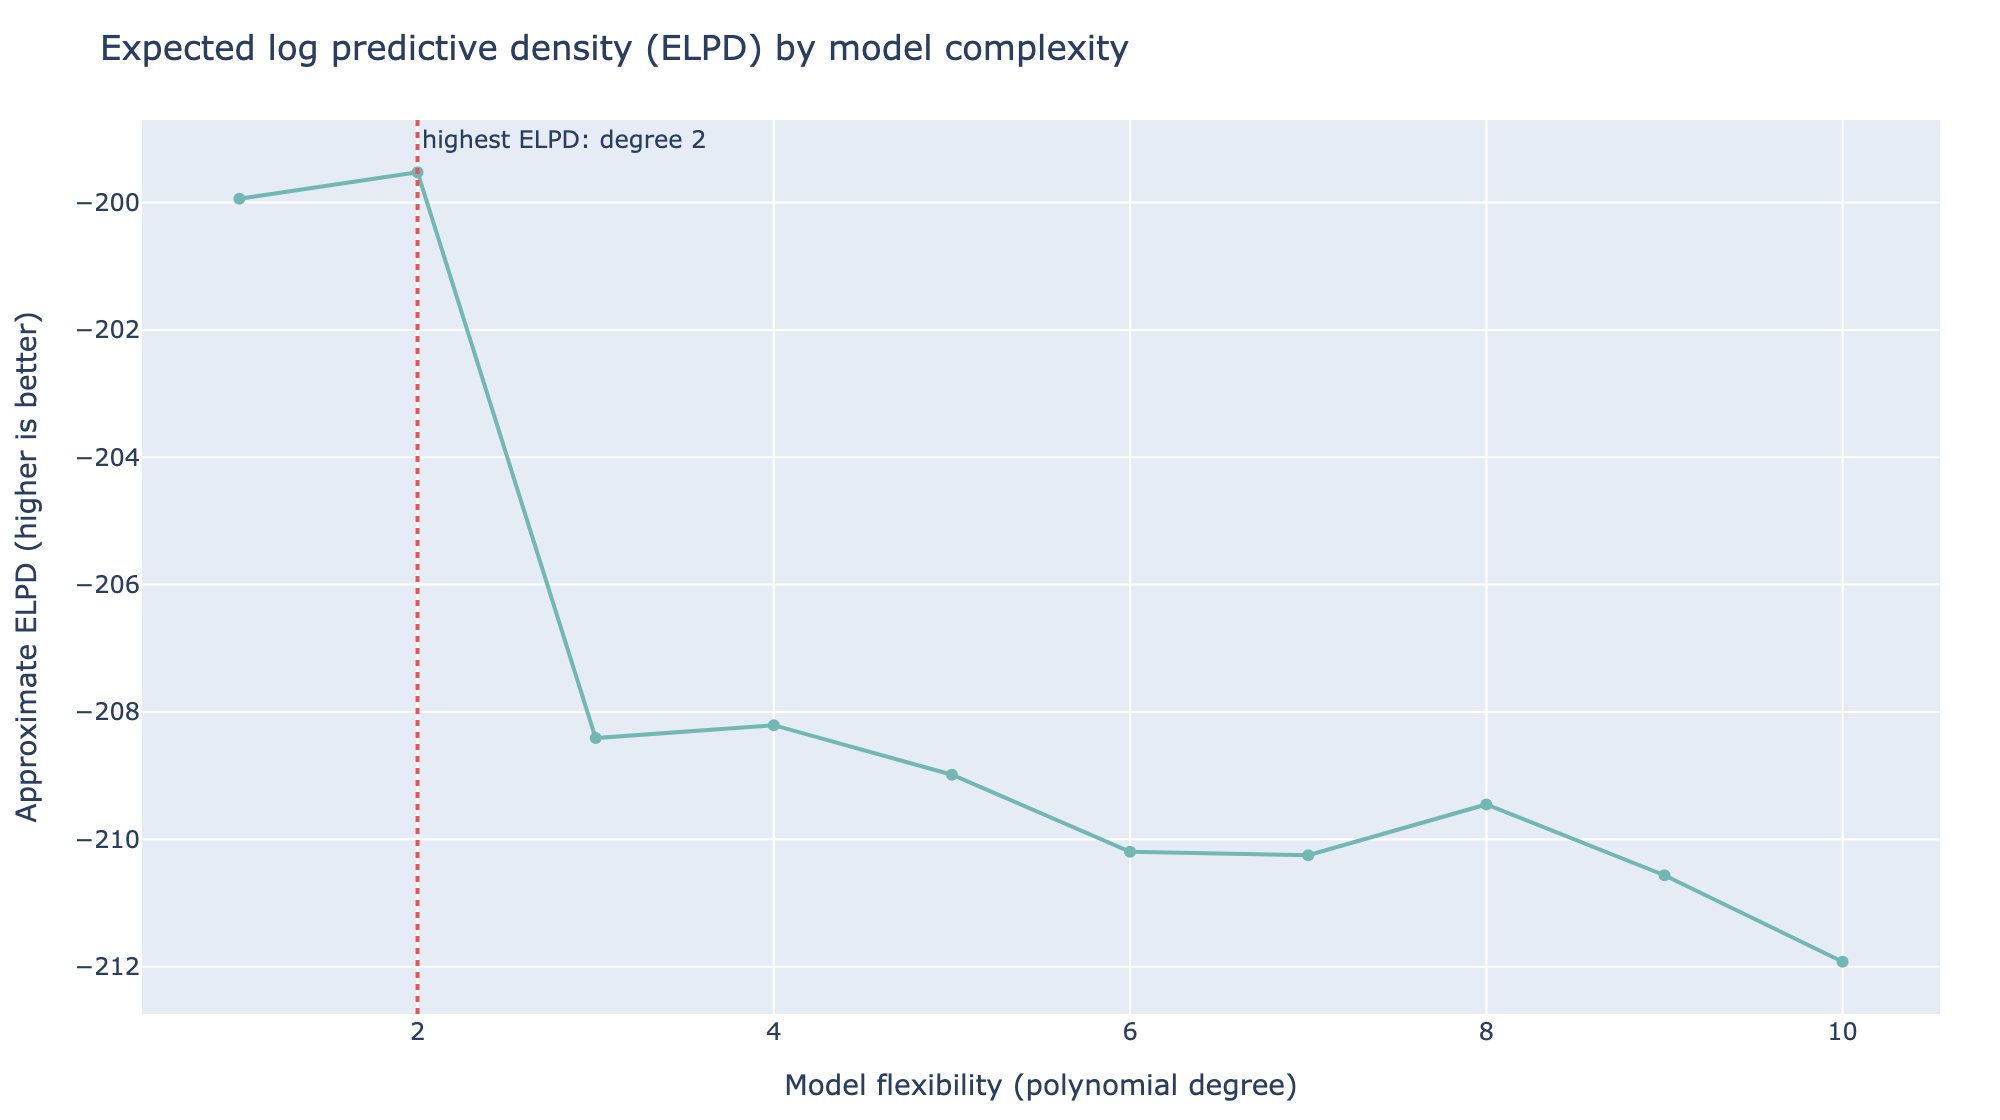

In [5]:
fig = FIGURES["chapter-cv-fig-elpd-by-complexity"]()
fig